In [7]:
import sys
sys.path.append('../')
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pickle
from tqdm.auto import tqdm
from scipy.stats import gaussian_kde, pearsonr

from utils import *
from experiment import unpack_and_dequantize
from model import probability_weighting, probability_weighting_goldstein_einhorn, probability_weighting_prelec

import matplotlib.pyplot as plt
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({"font.size" : 15,
                     "figure.dpi" : 100, 
                     "grid.alpha" : 0.3, 
                     "axes.grid": False, 
                     "axes.axisbelow" : True,
                     "figure.figsize":(8,6),
                     "mathtext.fontset":"cm",
                     "xtick.labelsize": 14,
                     "ytick.labelsize": 14,
                     "axes.labelsize": 16, 
                     "legend.fontsize": 13.5})
plt.rc("text", usetex=False)
plt.rc("font", family="serif")

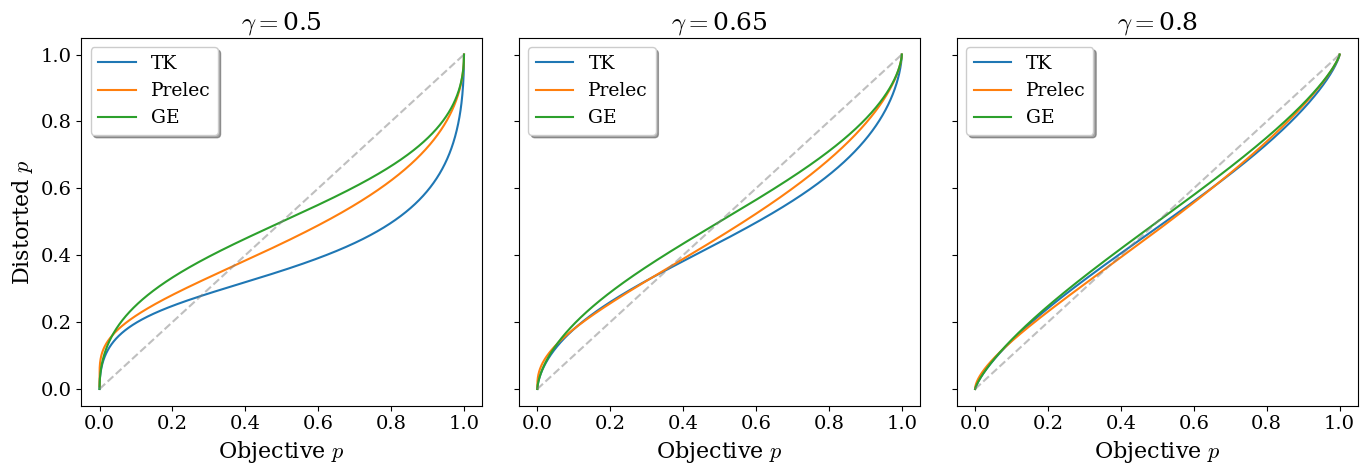

In [19]:
labels = ["TK", "Prelec", "GE"]
p = np.linspace(0, 1, 2000)

fig, axs= plt.subplots(1, 3, figsize=(14,5), sharey=True)

for k, g in enumerate([0.5, 0.65, 0.8]):
    for i,f in enumerate([probability_weighting, probability_weighting_prelec, probability_weighting_goldstein_einhorn]):
        axs[k].plot(p, f(p, gamma=g), label=labels[i])
    axs[k].set_title(r"$\gamma=$" + str(g))
    axs[k].legend(shadow=True)
    axs[k].set_xlabel(r"Objective $p$")
    if k == 0:
        axs[k].set_ylabel(r"Distorted $p$")
    axs[k].plot(np.linspace(0,1,1000), np.linspace(0,1,1000), linestyle="dashed", color="grey", alpha=0.5)

fig.tight_layout()
plt.savefig("../figures/probability_weighting_function_comparison.pdf", bbox_inches="tight")

plt.show()

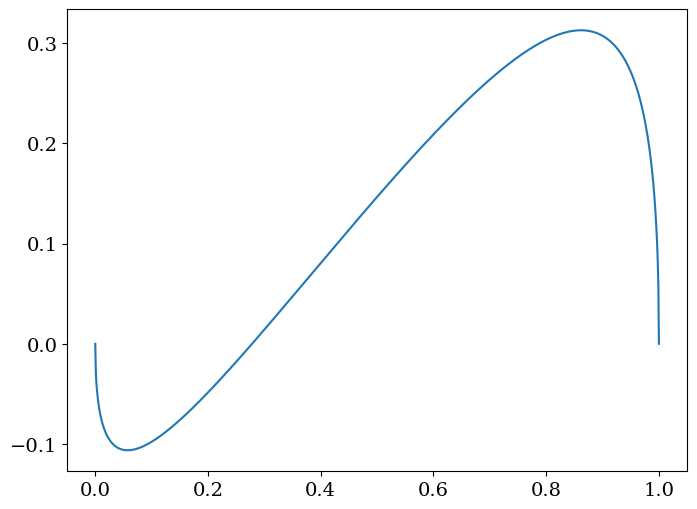

In [ ]:
pvals = np.linspace(0,1,1000)
plt.plot(
    pvals, pvals - probability_weighting(pvals, gamma=0.5)
)
plt.show()

In [6]:
pvals[np.argmin(pvals - probability_weighting(pvals, gamma=0.5))]

np.float64(0.057057057057057055)

In [ ]:
pvals[np.argmax(pvals - probability_weighting(pvals, gamma=0.5))]

np.float64(0.8618618618618619)

### Welfare

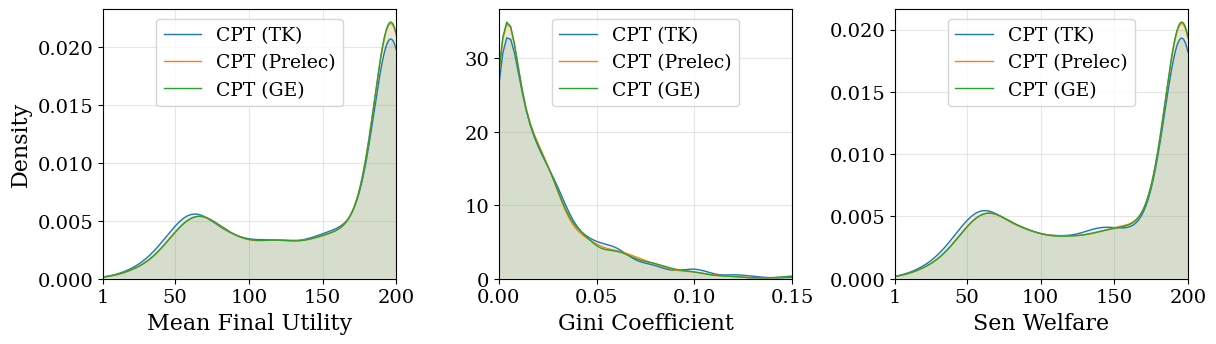

In [27]:
fig, axs = plt.subplots(1, 3, figsize=(14,3.5))
labels = ["CPT (TK)", "CPT (Prelec)", "CPT (GE)"]

# Mean Final Utility
for i, directory in enumerate(["../data/cpt/cpt_kt_95/", "../data/cpt/cpt_prelec_95/", "../data/cpt/cpt_ge_95/"]):
    with open(f"{directory}mean_util", "rb") as f:
        M = pickle.load(f)
    kde = gaussian_kde(M, bw_method=0.2)
    x_vals = np.linspace(1, 200, 500)
    y_vals = kde(x_vals)
    y_vals /= np.trapz(y_vals, x_vals)
    axs[0].plot(x_vals, y_vals, label=labels[i], lw=1)
    axs[0].fill_between(x_vals, y_vals, alpha=0.1)
axs[0].set_ylabel("Density")
axs[0].set_xlabel("Mean Final Utility")
axs[0].legend(loc="upper center")
axs[0].set_ylim(0,)
axs[0].set_xticks([1, 50, 100, 150, 200])
axs[0].grid()
axs[0].set_xlim(1,200)

# Gini Coefficient
for i, directory in enumerate(["../data/cpt/cpt_kt_95/", "../data/cpt/cpt_prelec_95/", "../data/cpt/cpt_ge_95/"]):
    with open(f"{directory}gini", "rb") as f:
        G = pickle.load(f)
    kde = gaussian_kde(G, bw_method=0.2)
    x_vals = np.linspace(min(G), 1, 500)
    y_vals = kde(x_vals)
    y_vals /= np.trapz(y_vals, x_vals)
    axs[1].plot(x_vals, y_vals, label=labels[i], lw=1)
    axs[1].fill_between(x_vals, y_vals, alpha=0.1)
axs[1].set_xlabel("Gini Coefficient")
axs[1].legend(loc="upper center")
axs[1].set_xlim(0, 0.15)
axs[1].grid()
axs[1].set_ylim(0,)

# Sen Welfare
for i, directory in enumerate(["../data/cpt/cpt_kt_95/", "../data/cpt/cpt_prelec_95/", "../data/cpt/cpt_ge_95/"]):
    with open(f"{directory}sen_welfare", "rb") as f:
        sen = pickle.load(f)
    kde = gaussian_kde(sen, bw_method=0.2)
    x_vals = np.linspace(1, 200, 500)
    y_vals = kde(x_vals)
    y_vals /= np.trapz(y_vals, x_vals)
    axs[2].plot(x_vals, y_vals, label=labels[i], lw=1)
    axs[2].fill_between(x_vals, y_vals, alpha=0.1)
axs[2].set_xlabel("Sen Welfare")
axs[2].set_xticks([1, 50, 100, 150, 200])
axs[2].legend(loc="upper center")
axs[2].grid()
axs[2].set_ylim(0,)
axs[2].set_xlim(1,200)

fig.subplots_adjust(wspace=0.35)
plt.savefig("../figures/cpt_comparison_weighting.pdf", bbox_inches="tight")
plt.show() 